# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

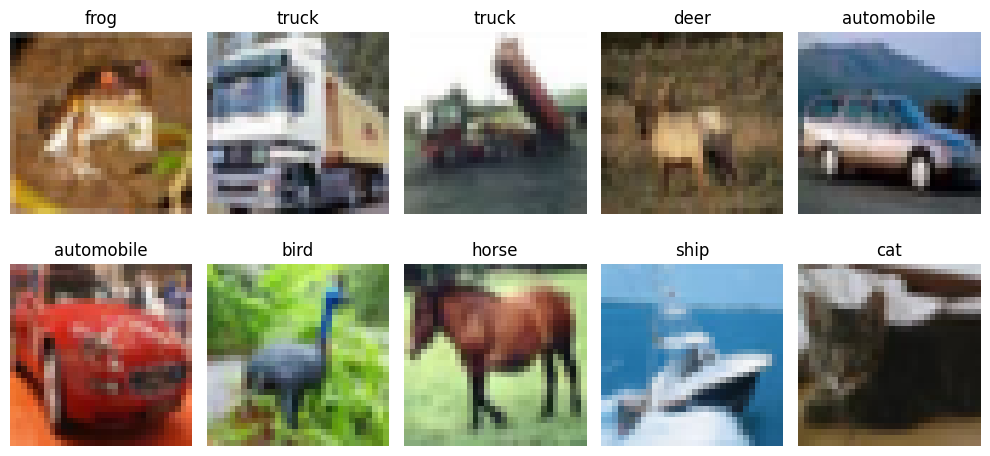

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
layers.Dropout(0.4),
layers.Dense(256, activation='relu'),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=12,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2502 - loss: 2.0277 - val_accuracy: 0.3114 - val_loss: 1.9228
Epoch 2/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.2909 - loss: 1.9201 - val_accuracy: 0.3368 - val_loss: 1.8835
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3132 - loss: 1.8701 - val_accuracy: 0.3438 - val_loss: 1.8161
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3239 - loss: 1.8396 - val_accuracy: 0.3376 - val_loss: 1.8271
Epoch 5/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.3350 - loss: 1.8193 - val_accuracy: 0.3582 - val_loss: 1.8126
Epoch 6/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3448 - loss: 1.7926 - val_accuracy: 0.3676 - val_loss: 1.7722
Epoch 7/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3500 - loss: 1.7804 - val_accuracy: 0.3748 - val_loss: 1.7665
Epoch 8/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3569 - loss: 1.7672 - 

Observation:
ANN achieved moderate accuracy because image pixels were flattened into vectors, resulting in loss of spatial information.

In [9]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4053 - loss: 1.7082
ANN Test Accuracy: 0.40529999136924744


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [11]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=12,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 138ms/step - accuracy: 0.4784 - loss: 1.4647 - val_accuracy: 0.4954 - val_loss: 1.4421
Epoch 2/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 141ms/step - accuracy: 0.6211 - loss: 1.0865 - val_accuracy: 0.5358 - val_loss: 1.3467
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 143ms/step - accuracy: 0.6808 - loss: 0.9194 - val_accuracy: 0.6716 - val_loss: 0.9320
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 143ms/step - accuracy: 0.7197 - loss: 0.8026 - val_accuracy: 0.6684 - val_loss: 0.9671
Epoch 5/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 143ms/step - accuracy: 0.7527 - loss: 0.7097 - val_accuracy: 0.7236 - val_loss: 0.8074
Epoch 6/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 137ms/step - accuracy: 0.7784 - loss: 0.6292 - val_accuracy: 0.7212 - val_loss: 0.8261
Epoch 7/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 141ms/step - accuracy: 0.8025 - loss: 0.5608 - val_accuracy: 0.6454 - val_loss: 1.1858
Epoch 8/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.8270 - l

In [12]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6965 - loss: 1.0682
CNN Test Accuracy: 0.6965000033378601


Observation:
CNN outperformed ANN by automatically learning important image features using convolutional layers.

## 📈 Compare Learning Curves

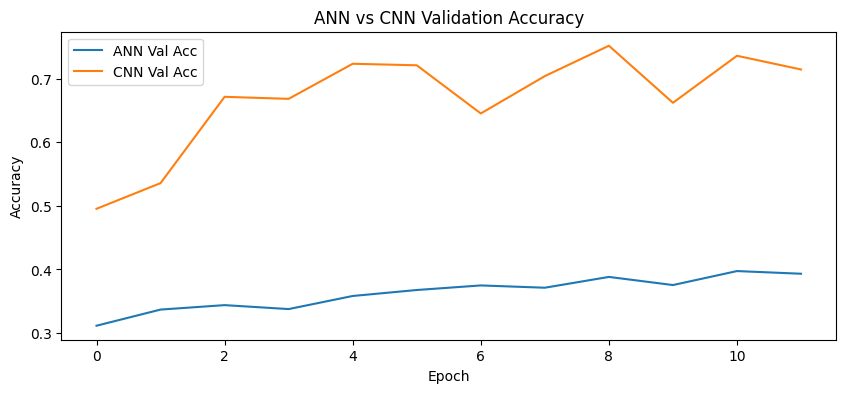

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [16]:
data_augmentation = tf.keras.Sequential([
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.15),
layers.RandomZoom(0.15),
layers.RandomContrast(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Observation:
Data augmentation improved generalization by exposing the model to transformed image samples.

# 📊 Final Comparison Table

In [17]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4053
1,CNN,0.6965


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## Final Conclusion

Three approaches were evaluated on the CIFAR-10 dataset.

1. ANN provided baseline performance.
2. CNN significantly improved classification accuracy.
3. CNN with data augmentation achieved the best generalization performance.

The experiment demonstrates that convolution-based architectures are more effective than traditional neural networks for image classification tasks.